In [4]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('../combined_fourth_downs_hardcount.csv')

# Check size first
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Rows: {len(df)}")
print(f"Categorical columns: {len(cat_cols)}")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

/tmp/ipykernel_5481/4176434758.py:4: DtypeWarning: Columns (0: lateral_receiver_player_id, 1: lateral_receiver_player_name, 2: lateral_rusher_player_id, 3: lateral_rusher_player_name, 4: lateral_interception_player_id, 5: lateral_interception_player_name, 6: lateral_punt_returner_player_id, 7: lateral_punt_returner_player_name, 8: qb_hit_2_player_id, 9: qb_hit_2_player_name, 10: pass_defense_2_player_id, 11: pass_defense_2_player_name, 12: fumbled_2_player_id, 13: fumbled_2_player_name, 14: fumbled_2_team, 15: fumble_recovery_2_team, 16: fumble_recovery_2_player_id, 17: fumble_recovery_2_player_name, 18: half_sack_1_player_id, 19: half_sack_1_player_name, 20: half_sack_2_player_id, 21: half_sack_2_player_name, 22: safety_player_name, 23: safety_player_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../combined_fourth_downs_hardcount.csv')
/tmp/ipykernel_5481/4176434758.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are i

Rows: 38762
Categorical columns: 139
  game_id: 2226 unique values
  home_team: 32 unique values
  away_team: 32 unique values
  season_type: 2 unique values
  posteam: 32 unique values
  posteam_type: 2 unique values
  defteam: 32 unique values
  side_of_field: 33 unique values
  game_date: 483 unique values
  game_half: 3 unique values
  time: 900 unique values
  yrdln: 1569 unique values
  desc: 35141 unique values
  play_type: 6 unique values
  pass_length: 2 unique values
  pass_location: 3 unique values
  run_location: 3 unique values
  run_gap: 3 unique values
  field_goal_result: 3 unique values
  timeout_team: 32 unique values
  td_team: 32 unique values
  td_player_name: 420 unique values
  td_player_id: 427 unique values
  passer_player_id: 199 unique values
  passer_player_name: 202 unique values
  receiver_player_id: 783 unique values
  receiver_player_name: 765 unique values
  rusher_player_id: 486 unique values
  rusher_player_name: 487 unique values
  lateral_receiver_p

In [5]:
## Function that can be universally applied to any team column to reduce dimensionality
def create_is_posteam_column(df, team_col):
    """
    This function takes in a dataframe and a team column name, creates a new column indicating whether the team in the specified column is the same as the posteam, and drops the old team column.
    Args:
        df (pd.DataFrame): The input dataframe.
        team_col (str): The name of the team column to compare with posteam.
    Returns:
        pd.DataFrame: The modified dataframe with the new is_posteam column and the old team column dropped.
    Example:
        df = create_is_posteam_column(df, 'home_team')
        Result would be df, with the new column 'home_is_posteam' and the old 'home_team' column dropped.
    """
    new_col_name = team_col.replace('_team', '_is_posteam')
    df[new_col_name] = (df[team_col] == df['posteam']).astype(int)
    ## Drop old team column
    df = df.drop(columns=[team_col])
    return df

In [15]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

def encode_categoricals(df):
    df_encoded = df.copy()
    
    # Columns to drop
    drop_cols = [
    # Original drops
    'desc', 'yrdln', 'time', 'game_date',
    'start_time', 'time_of_day', 'end_clock_time',
    'drive_game_clock_start', 'drive_game_clock_end', 'drive_real_start_time',
    'drive_start_yard_line', 'drive_end_yard_line',
    'weather', 'stadium', 'game_stadium',
    'home_coach', 'away_coach',
    'passer', 'rusher', 'receiver', 'name', 'fantasy',
    'penalty_type',
    
    # IDs
    'play_id', 'game_id', 'old_game_id', 'nfl_api_id', 'stadium_id', 'id',
    'drive_play_id_started', 'drive_play_id_ended',
    'passer_id', 'rusher_id', 'receiver_id',
    'fantasy_player_id', 'fantasy_id',
    
    # Player IDs and names
    'td_player_name', 'td_player_id',
    'passer_player_id', 'passer_player_name',
    'receiver_player_id', 'receiver_player_name',
    'rusher_player_id', 'rusher_player_name',
    'lateral_receiver_player_id', 'lateral_receiver_player_name',
    'lateral_rusher_player_id', 'lateral_rusher_player_name',
    'lateral_sack_player_id', 'lateral_sack_player_name',
    'interception_player_id', 'interception_player_name',
    'lateral_interception_player_id', 'lateral_interception_player_name',
    'punt_returner_player_id', 'punt_returner_player_name',
    'lateral_punt_returner_player_id', 'lateral_punt_returner_player_name',
    'kickoff_returner_player_name', 'kickoff_returner_player_id',
    'lateral_kickoff_returner_player_id', 'lateral_kickoff_returner_player_name',
    'punter_player_id', 'punter_player_name',
    'kicker_player_name', 'kicker_player_id',
    'own_kickoff_recovery_player_id', 'own_kickoff_recovery_player_name',
    'blocked_player_id', 'blocked_player_name',
    'tackle_for_loss_1_player_id', 'tackle_for_loss_1_player_name',
    'tackle_for_loss_2_player_id', 'tackle_for_loss_2_player_name',
    'qb_hit_1_player_id', 'qb_hit_1_player_name',
    'qb_hit_2_player_id', 'qb_hit_2_player_name',
    'forced_fumble_player_1_team', 'forced_fumble_player_1_player_id', 'forced_fumble_player_1_player_name',
    'forced_fumble_player_2_team', 'forced_fumble_player_2_player_id', 'forced_fumble_player_2_player_name',
    'solo_tackle_1_team', 'solo_tackle_2_team',
    'solo_tackle_1_player_id', 'solo_tackle_2_player_id',
    'solo_tackle_1_player_name', 'solo_tackle_2_player_name',
    'assist_tackle_1_player_id', 'assist_tackle_1_player_name', 'assist_tackle_1_team',
    'assist_tackle_2_player_id', 'assist_tackle_2_player_name', 'assist_tackle_2_team',
    'assist_tackle_3_player_id', 'assist_tackle_3_player_name', 'assist_tackle_3_team',
    'assist_tackle_4_player_id', 'assist_tackle_4_player_name', 'assist_tackle_4_team',
    'tackle_with_assist', 'tackle_with_assist_1_player_id', 'tackle_with_assist_1_player_name', 'tackle_with_assist_1_team',
    'tackle_with_assist_2_player_id', 'tackle_with_assist_2_player_name', 'tackle_with_assist_2_team',
    'pass_defense_1_player_id', 'pass_defense_1_player_name',
    'pass_defense_2_player_id', 'pass_defense_2_player_name',
    'fumbled_1_player_id', 'fumbled_1_player_name',
    'fumbled_2_player_id', 'fumbled_2_player_name', 'fumbled_2_team',
    'fumble_recovery_1_player_id', 'fumble_recovery_1_player_name',
    'fumble_recovery_2_team', 'fumble_recovery_2_player_id', 'fumble_recovery_2_player_name',
    'sack_player_id', 'sack_player_name',
    'half_sack_1_player_id', 'half_sack_1_player_name',
    'half_sack_2_player_id', 'half_sack_2_player_name',
    'penalty_player_id', 'penalty_player_name',
    'safety_player_name', 'safety_player_id',
    'fantasy_player_name',
    
    # Other columns from your list
    'side_of_field', 'quarter_end', 'timeout', 'timeout_team',
    'extra_point_result', 'two_point_conv_result',
    'lateral_receiving_yards', 'lateral_rushing_yards',
    'fumble_recovery_1_yards', 'fumble_recovery_2_yards',
    'replay_or_challenge', 'replay_or_challenge_result',
    'defensive_two_point_attempt', 'defensive_two_point_conv',
    'defensive_extra_point_attempt', 'defensive_extra_point_conv',
    'play_clock', 'play_deleted', 'st_play_type', 'end_yard_line', 'qb_kneel', 'qb_spike',
    'aborted_play', 'passer_jersey_number', 'rusher_jersey_number', 'receiver_jersey_number',
    'jersey_number', 'home_opening_kickoff', 'kickoff_inside_twenty', 'kickoff_in_endzone', 
    'kickoff_out_of_bounds', 'kickoff_downed', 'kickoff_fair_catch',
    'wp', 'def_wp', 'home_wp', 'away_wp', 'wpa', 'vegas_wpa', 'vegas_home_wpa', 'home_wp_post', 
    'away_wp_post', 'vegas_wp', 'vegas_home_wp', 'total_home_rush_wpa', 'total_away_rush_wpa', 
    'total_home_pass_wpa', 'total_away_pass_wpa', 'air_wpa', 'yac_wpa', 'comp_air_wpa', 'comp_yac_wpa', 
    'total_home_comp_air_wpa', 'total_away_comp_air_wpa',     'total_home_comp_yac_wpa', 
    'total_away_comp_yac_wpa', 'total_home_raw_air_wpa', 'total_away_raw_air_wpa', 
    'total_home_raw_yac_wpa', 'total_away_raw_yac_wpa', 'qb_epa', 'xyac_epa', 
    'first_down_rush', 'first_down_pass', 'first_down_penalty', 'third_down_converted', 'third_down_failed', 
]
    
    # One-hot encode (nominal categories)
    onehot_cols = [
        'posteam', 'defteam',
        'season_type', 'posteam_type', 'game_half',
        'play_type', 'play_type_nfl',
        'pass_length', 'pass_location',
        'run_location', 'run_gap',
        'field_goal_result', 'series_result',
        'drive_start_transition', 'drive_end_transition', 'fixed_drive_result',
        'roof', 'surface', 'location', 'playcaller'
    ]

    team_cols = [
        'home_team',
        'away_team',
        'td_team',
        'penalty_team',
        'return_team',
        'fumbled_1_team',
        'fumble_recovery_1_team'
    ]
    
    # Label encode (ordinal)
    label_cols = [
        'week', 'qtr', 'down', 'drive', 'fixed_drive',
        'order_sequence', 'series',
    ]
    
    # Drop unwanted columns
    df_encoded = df_encoded.drop(columns=drop_cols, errors='ignore')
    
    # Apply team column function
    for col in team_cols:
        create_is_posteam_column(df_encoded, col)

    # One-hot encode
    onehot_cols_present = [col for col in onehot_cols if col in df_encoded.columns]
    if onehot_cols_present:
        df_encoded = pd.get_dummies(df_encoded, columns=onehot_cols_present, drop_first=True)
    
    # Label encode
    le = LabelEncoder()
    for col in label_cols:
        if col in df_encoded.columns:
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    
    remaining_objects = df_encoded.select_dtypes(include=['object', 'str']).columns.tolist()
    df_encoded = df_encoded.drop(columns=remaining_objects, errors='ignore')
    
    return df_encoded


In [16]:
df_encoded = encode_categoricals(df)


In [17]:
# Check shape before and after
print(f"Original shape: {df.shape}")
print(f"Encoded shape: {df_encoded.shape}")

# Check data types (should be mostly numeric now)
print(f"\nData types:\n{df_encoded.dtypes.value_counts()}")

# See the new column names (especially one-hot encoded ones)
print(f"\nColumns:\n{df_encoded.columns.tolist()}")

# Check for any remaining object columns
remaining_objects = df_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"\nRemaining object columns: {remaining_objects}")

# Preview the data
df_encoded.head()

Original shape: (38762, 376)
Encoded shape: (38762, 385)

Data types:
bool       232
float64     99
int64       54
Name: count, dtype: int64

Columns:
['is_fourth_down', 'is_hard_count', 'week', 'yardline_100', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'ydstogo', 'ydsnet', 'yards_gained', 'shotgun', 'no_huddle', 'qb_dropback', 'qb_scramble', 'air_yards', 'yards_after_catch', 'kick_distance', 'home_timeouts_remaining', 'away_timeouts_remaining', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'total_home_score', 'total_away_score', 'posteam_score', 'defteam_score', 'score_differential', 'posteam_score_post', 'defteam_score_post', 'score_differential_post', 'no_score_prob', 'opp_fg_prob', 'opp_safety_prob', 'opp_td_prob', 'fg_prob', 'safety_prob', 'td_prob', 'extra_point_prob', 'two_point_conversion_prob', 'ep', 'epa', 'total_home_epa', 'total_away_epa', 'total_home_rush_epa', 'total_away_rush_

,is_fourth_down,is_hard_count,week,yardline_100,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,drive,sp,qtr,...,playcaller_Shane Steichen,playcaller_Shane Waldron,playcaller_Steve Sarkisian,playcaller_Thomas Brown,playcaller_Tim Kelly,playcaller_Todd Downing,playcaller_Todd Haley,playcaller_Todd Monken,playcaller_Zac Robinson,playcaller_Zac Taylor
0,0,1,11,60.0,826,1726,3526,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,1,5,72.0,814,1714,3514,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0,1,0,67.0,861,1761,3561,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,1,0,17,83.0,787,1687,3487,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,1,0,16,76.0,819,1719,3519,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [11]:
print(df_encoded.isnull().sum().sum())
null_counts = df_encoded.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False).head(30))

df_encoded = df_encoded.fillna(0)

# Verify
print(f"Remaining nulls: {df_encoded.isnull().sum().sum()}")

693799
yards_after_catch             36581
passing_yards                 36581
receiving_yards               36581
rushing_yards                 36199
xyac_median_yardage           35544
xyac_fd                       35544
xyac_success                  35544
xyac_mean_yardage             35544
penalty_yards                 34923
cp                            34921
cpoe                          34921
air_wpa                       34799
yac_wpa                       34799
yac_epa                       34799
air_epa                       34799
air_yards                     34798
pass_oe                       31602
xpass                         29839
temp                          14138
wind                          14138
kick_distance                 10703
home_wp_post                   1944
away_wp_post                   1944
score_differential             1670
defteam_timeouts_remaining     1670
defteam_score                  1670
posteam_score                  1670
posteam_timeouts_rema

In [34]:

df_encoded.to_csv('../encoded_fourth_downs.csv.gz', index=False, compression='gzip')

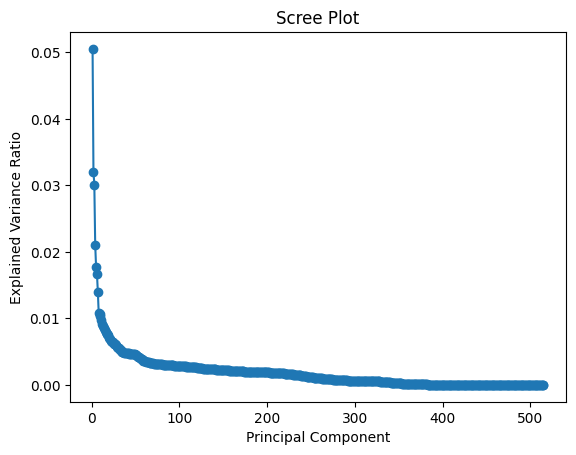

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# --- Standardize features ---
scaler = StandardScaler()
df_encoded_scaled = scaler.fit_transform(df_encoded)

# --- Fit PCA ---
pca = PCA()
df_encoded_pca = pca.fit_transform(df_encoded_scaled)

# Convert to DataFrame (optional)
pca_df = pd.DataFrame(
    df_encoded_pca,
    columns=[f"PC{i+1}" for i in range(df_encoded_pca.shape[1])]
)

import matplotlib.pyplot as plt

explained = pca.explained_variance_ratio_

plt.plot(range(1, len(explained)+1), explained, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

In [23]:
pca = PCA(n_components=0.95)
df_encoded_reduced = pca.fit_transform(df_encoded_scaled)

print("Number of components retained:", pca.n_components_)

Number of components retained: 274


In [25]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=df_encoded.columns
)

print(loadings)

                                 PC1       PC2       PC3       PC4       PC5  \
is_fourth_down              0.022420 -0.053851 -0.014151  0.048252 -0.084529   
is_hard_count              -0.023330  0.052328  0.013763 -0.045180  0.089809   
week                        0.000163  0.001680  0.002793  0.000696 -0.002198   
yardline_100                0.105811 -0.162187 -0.047002  0.028275  0.004089   
quarter_seconds_remaining   0.040563 -0.028603 -0.004797  0.068086 -0.035615   
...                              ...       ...       ...       ...       ...   
fumble_recovery_1_team_SEA  0.000971 -0.001710 -0.001893  0.001894  0.009915   
fumble_recovery_1_team_SF   0.004047 -0.003604 -0.001127  0.001682  0.004074   
fumble_recovery_1_team_TB   0.002241 -0.005105 -0.000853  0.000647  0.006804   
fumble_recovery_1_team_TEN  0.002520 -0.003448  0.000080  0.000450  0.003695   
fumble_recovery_1_team_WAS  0.001740 -0.003919 -0.001536 -0.000723  0.006116   

                                 PC6   